In [7]:
!pip install sentencepiece

In [1]:
%%writefile "C:/Users/nivsa/Generation of Synthetic Training Data/embedded/extraction_engine/evaluate.py"
"""
evaluate.py — Evaluation script for JointNERRE model
------------------------------------------------------
FIX: הוספת Negative Sampling להערכה ריאליסטית של RE.
     המודל נבחן גם על זוגות ישויות ללא קשר (NEGATIVE),
     בדיוק כמו שאומן.
"""

import argparse
import json
import os
import random
import warnings
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import DebertaV2Model, DebertaV2TokenizerFast
from seqeval.metrics import classification_report as seq_classification_report
from sklearn.metrics import classification_report as sk_classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")
import seaborn as sns
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning, module="seqeval")

IGNORE_INDEX = -100

NER_LABEL2ID = {
    "O": 0,
    "B-PARAMETER": 1, "I-PARAMETER": 2,
    "B-VALUE":     3, "I-VALUE":     4,
    "B-MIN":       5, "I-MIN":       6,
    "B-MAX":       7, "I-MAX":       8,
    "B-TYP":       9, "I-TYP":       10,
    "B-UNIT":     11, "I-UNIT":      12,
    "B-CONDITION":13, "I-CONDITION": 14,
}
NER_ID2LABEL = {v: k for k, v in NER_LABEL2ID.items()}

REL_LABEL2ID = {
    "NEGATIVE":       0,
    "has_value":      1,
    "has_unit":       2,
    "has_min":        3,
    "has_max":        4,
    "has_typ":        5,
    "has_condition":  6,
}
REL_ID2LABEL = {v: k for k, v in REL_LABEL2ID.items()}

MAX_TOKENS    = 512
MAX_REL_PAIRS = 64


class JointNERRE(nn.Module):
    def __init__(self, model_name, num_ner_labels, num_rel_labels,
                 dropout=0.1, alpha=1.0, beta=0.5):
        super().__init__()
        self.alpha, self.beta = alpha, beta
        self.encoder     = DebertaV2Model.from_pretrained(model_name)
        hidden_size      = self.encoder.config.hidden_size
        self.ner_dropout = nn.Dropout(dropout)
        self.ner_head    = nn.Linear(hidden_size, num_ner_labels)
        self.re_dropout  = nn.Dropout(dropout)
        self.re_head     = nn.Linear(hidden_size * 2, num_rel_labels)

    @staticmethod
    def _mean_pool_span(hidden_states, spans):
        B, num_rels, _ = spans.shape
        H      = hidden_states.size(-1)
        pooled = torch.zeros(B, num_rels, H, device=hidden_states.device)
        for b in range(B):
            for r in range(num_rels):
                start = spans[b, r, 0].item()
                end   = spans[b, r, 1].item() + 1
                if end > start:
                    pooled[b, r] = hidden_states[b, start:end].mean(dim=0)
        return pooled

    def forward(self, input_ids, attention_mask, token_type_ids,
                ner_labels=None, head_spans=None, tail_spans=None,
                rel_labels=None, rel_mask=None):
        outputs         = self.encoder(input_ids=input_ids,
                                       attention_mask=attention_mask,
                                       token_type_ids=token_type_ids)
        sequence_output = outputs.last_hidden_state.float()
        ner_logits      = self.ner_head(self.ner_dropout(sequence_output))

        re_logits = None
        if head_spans is not None and tail_spans is not None and head_spans.size(1) > 0:
            head_repr = self._mean_pool_span(sequence_output, head_spans)
            tail_repr = self._mean_pool_span(sequence_output, tail_spans)
            re_logits = self.re_head(
                self.re_dropout(torch.cat([head_repr, tail_repr], dim=-1))
            )

        return {"ner_logits": ner_logits, "re_logits": re_logits}


def span_to_start_end(token_indices):
    return (min(token_indices), max(token_indices))


# ==============================================================================
# FIX: build_rel_tensors עם Negative Sampling
# ==============================================================================
def build_rel_tensors(relations, seq_len, ner_tags_subword,
                      max_pairs=MAX_REL_PAIRS, neg_ratio=1.0):
    """
    בונה tensors לקשרים כולל negative pairs.

    FIX: הוספת negative pairs — זוגות ישויות שאין ביניהן קשר.
    זה חיוני כדי שהמדדים ישקפו את ביצועי המודל בעולם האמיתי,
    שם רוב הזוגות אינם בעלי קשר.

    Args:
        relations:        רשימת קשרים חיוביים מה-ground truth
        seq_len:          אורך הרצף בפועל (לא כולל padding)
        ner_tags_subword: תגיות NER ברמת subword לזיהוי ישויות
        max_pairs:        מקסימום זוגות בסך הכל
        neg_ratio:        יחס negatives לפוזיטיביות (1.0 = שווה)
    """
    head_spans = torch.zeros(max_pairs, 2, dtype=torch.long)
    tail_spans = torch.zeros(max_pairs, 2, dtype=torch.long)
    rel_labels = torch.zeros(max_pairs, dtype=torch.long)
    rel_mask   = torch.zeros(max_pairs, dtype=torch.bool)

    positive_pairs = set()
    filled = 0

    # --- קשרים חיוביים ---
    for rel in relations:
        if filled >= max_pairs:
            break
        h_start, h_end = span_to_start_end(rel["head"])
        t_start, t_end = span_to_start_end(rel["tail"])
        if h_end < seq_len and t_end < seq_len:
            head_spans[filled] = torch.tensor([h_start, h_end])
            tail_spans[filled] = torch.tensor([t_start, t_end])
            rel_labels[filled] = REL_LABEL2ID.get(rel["type"], 0)
            rel_mask[filled]   = True
            positive_pairs.add((h_start, t_start))
            positive_pairs.add((t_start, h_start))
            filled += 1

    num_positives = filled

    # --- FIX: Negative pairs ---
    # מציאת כל ישויות ה-B- ברצף (ראשי entities)
    entity_starts = [
        i for i, tag_id in enumerate(ner_tags_subword[:seq_len])
        if tag_id != IGNORE_INDEX and NER_ID2LABEL.get(tag_id, "O").startswith("B-")
    ]

    num_negatives_target = max(1, int(num_positives * neg_ratio))
    candidate_pairs = [
        (i, j)
        for i in entity_starts
        for j in entity_starts
        if i != j and (i, j) not in positive_pairs
    ]
    random.shuffle(candidate_pairs)

    for h_start, t_start in candidate_pairs[:num_negatives_target]:
        if filled >= max_pairs:
            break
        head_spans[filled] = torch.tensor([h_start, h_start])
        tail_spans[filled] = torch.tensor([t_start, t_start])
        rel_labels[filled] = REL_LABEL2ID["NEGATIVE"]
        rel_mask[filled]   = True
        filled += 1

    return head_spans, tail_spans, rel_labels, rel_mask


class DatasheetDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=MAX_TOKENS):
        self.samples   = data
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        tokens = sample["tokens"]
        tags   = sample["ner_tags"]

        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        input_ids      = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)
        token_type_ids = encoding.get("token_type_ids",
                         torch.zeros_like(input_ids)).squeeze(0)
        word_ids       = encoding.word_ids(batch_index=0)

        ner_labels = torch.full((self.max_len,), IGNORE_INDEX, dtype=torch.long)
        prev_word  = None
        for i, wid in enumerate(word_ids):
            if wid is None:
                continue
            if wid != prev_word:
                label_str     = tags[wid] if wid < len(tags) else "O"
                ner_labels[i] = NER_LABEL2ID.get(label_str, 0)
            prev_word = wid

        word_to_first_subword = {}
        prev_word = None
        for i, wid in enumerate(word_ids):
            if wid is not None and wid != prev_word:
                word_to_first_subword[wid] = i
            prev_word = wid

        remapped_relations = []
        for rel in sample.get("relations", []):
            head_sw = [word_to_first_subword[t] for t in rel["head"]
                       if t in word_to_first_subword]
            tail_sw = [word_to_first_subword[t] for t in rel["tail"]
                       if t in word_to_first_subword]
            if head_sw and tail_sw:
                remapped_relations.append({
                    "head": head_sw,
                    "tail": tail_sw,
                    "type": rel["type"],
                })

        seq_len = attention_mask.sum().item()

        # FIX: מעביר ner_labels לבניית negative pairs
        head_spans, tail_spans, rel_labels, rel_mask = build_rel_tensors(
            remapped_relations,
            seq_len,
            ner_tags_subword=ner_labels.tolist(),  # FIX: חדש
            neg_ratio=1.0,                          # FIX: 1:1 pos/neg
        )

        return {
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "token_type_ids": token_type_ids,
            "ner_labels":     ner_labels,
            "head_spans":     head_spans,
            "tail_spans":     tail_spans,
            "rel_labels":     rel_labels,
            "rel_mask":       rel_mask,
        }


def decode_ner_predictions(all_preds, all_labels):
    pred_seqs, true_seqs = [], []
    for preds, labels in zip(all_preds, all_labels):
        pred_seq, true_seq = [], []
        for p, l in zip(preds, labels):
            if l == IGNORE_INDEX:
                continue
            pred_seq.append(NER_ID2LABEL.get(p, "O"))
            true_seq.append(NER_ID2LABEL.get(l, "O"))
        pred_seqs.append(pred_seq)
        true_seqs.append(true_seq)
    return pred_seqs, true_seqs


def plot_confusion_matrix(cm, labels, title, save_path):
    fig, ax = plt.subplots(figsize=(max(8, len(labels)), max(7, len(labels) - 1)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Saved: {save_path}")


@torch.no_grad()
def run_evaluation(model, loader, device):
    model.eval()

    all_ner_preds, all_ner_labels = [], []
    all_rel_preds, all_rel_labels = [], []

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out   = model(
            input_ids      = batch["input_ids"],
            attention_mask = batch["attention_mask"],
            token_type_ids = batch["token_type_ids"],
            head_spans     = batch["head_spans"],
            tail_spans     = batch["tail_spans"],
        )

        ner_preds = out["ner_logits"].argmax(dim=-1).cpu().tolist()
        ner_labs  = batch["ner_labels"].cpu().tolist()
        all_ner_preds.extend(ner_preds)
        all_ner_labels.extend(ner_labs)

        if out["re_logits"] is not None:
            re_preds = out["re_logits"].argmax(dim=-1)
            rel_mask = batch["rel_mask"]
            rel_labs = batch["rel_labels"]
            all_rel_preds.extend(re_preds[rel_mask].cpu().tolist())
            all_rel_labels.extend(rel_labs[rel_mask].cpu().tolist())

    return all_ner_preds, all_ner_labels, all_rel_preds, all_rel_labels


def main(args):
    os.makedirs(args.output_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n{'='*60}")
    print(f"  Device : {device}")
    print(f"  Model  : {args.model_path}")
    print(f"  Data   : {args.val_path}")
    print(f"{'='*60}\n")

    with open(args.val_path, encoding="utf-8") as f:
        raw = json.load(f)
    print(f"Loaded {len(raw)} validation samples.")

    tokenizer = DebertaV2TokenizerFast.from_pretrained(args.model_name)
    dataset   = DatasheetDataset(raw, tokenizer)
    loader    = DataLoader(dataset, batch_size=args.batch_size, shuffle=False)

    model = JointNERRE(
        model_name     = args.model_name,
        num_ner_labels = len(NER_LABEL2ID),
        num_rel_labels = len(REL_LABEL2ID),
    ).to(device)

    state = torch.load(args.model_path, map_location=device)
    if isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    model.load_state_dict(state, strict=False)
    print("Model loaded successfully.\n")

    ner_preds, ner_labels, rel_preds, rel_labels = run_evaluation(
        model, loader, device
    )

    pred_seqs, true_seqs = decode_ner_predictions(ner_preds, ner_labels)

    print("=" * 60)
    print("  NER — Entity-Level Report (seqeval)")
    print("=" * 60)
    ner_report = seq_classification_report(true_seqs, pred_seqs, digits=4)
    print(ner_report)

    ner_report_path = os.path.join(args.output_dir, "ner_report.txt")
    with open(ner_report_path, "w") as f:
        f.write(ner_report)
    print(f"  Saved: {ner_report_path}\n")

    flat_true = [l for sublist in ner_labels
                 for l in sublist if l != IGNORE_INDEX]
    flat_pred = [p for plist, llist in zip(ner_preds, ner_labels)
                 for p, l in zip(plist, llist) if l != IGNORE_INDEX]
    used_ids  = sorted(set(flat_true + flat_pred))
    used_lbls = [NER_ID2LABEL[i] for i in used_ids]
    cm_ner    = confusion_matrix(flat_true, flat_pred, labels=used_ids)
    plot_confusion_matrix(
        cm_ner, used_lbls,
        "NER Confusion Matrix (token-level)",
        os.path.join(args.output_dir, "ner_confusion_matrix.png"),
    )

    if rel_preds:
        print("=" * 60)
        print("  Relation Extraction Report (with Negatives)")
        print("=" * 60)

        # הוספת הערה על negative sampling
        neg_count = rel_labels.count(REL_LABEL2ID["NEGATIVE"])
        pos_count = len(rel_labels) - neg_count
        print(f"  Positive pairs: {pos_count}  |  Negative pairs: {neg_count}\n")

        rel_label_names = [REL_ID2LABEL[i]
                           for i in sorted(set(rel_labels + rel_preds))]
        re_report = sk_classification_report(
            rel_labels, rel_preds,
            target_names=rel_label_names,
            digits=4,
            zero_division=0,
        )
        print(re_report)

        re_report_path = os.path.join(args.output_dir, "re_report.txt")
        with open(re_report_path, "w") as f:
            f.write(f"Positive pairs: {pos_count}  |  Negative pairs: {neg_count}\n\n")
            f.write(re_report)
        print(f"  Saved: {re_report_path}\n")

        used_rel_ids  = sorted(set(rel_labels + rel_preds))
        used_rel_lbls = [REL_ID2LABEL[i] for i in used_rel_ids]
        cm_re         = confusion_matrix(rel_labels, rel_preds,
                                         labels=used_rel_ids)
        plot_confusion_matrix(
            cm_re, used_rel_lbls,
            "RE Confusion Matrix (with Negatives)",
            os.path.join(args.output_dir, "re_confusion_matrix.png"),
        )
    else:
        print("No relation predictions found — skipping RE report.\n")

    print("=" * 60)
    print("  Qualitative Examples (first 3 samples)")
    print("=" * 60)
    qual_path = os.path.join(args.output_dir, "qualitative_examples.txt")
    with open(qual_path, "w", encoding="utf-8") as f:
        for sample, pred_seq, true_seq in zip(raw[:3], pred_seqs[:3], true_seqs[:3]):
            f.write(f"\n{'─'*50}\n")
            f.write(f"ID: {sample['id']}\n")
            f.write(f"{'TOKEN':<25} {'PREDICTED':<18} {'GROUND TRUTH'}\n")
            f.write(f"{'─'*60}\n")
            tokens = [t for t in sample["tokens"] if t.strip()]
            for tok, pred, true in zip(tokens, pred_seq, true_seq):
                marker = "  ✗" if pred != true else ""
                f.write(f"{tok:<25} {pred:<18} {true}{marker}\n")
    print(f"  Saved: {qual_path}\n")


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--model_path", required=True,
                        help="Path to best_model.pt")
    parser.add_argument("--val_path",   required=True,
                        help="Path to validation JSON file")
    parser.add_argument("--model_name", default="microsoft/deberta-v3-base",
                        help="HuggingFace model name (must match training)")
    parser.add_argument("--output_dir", default="./eval_results",
                        help="Directory to save reports and plots")
    parser.add_argument("--batch_size", type=int, default=8)
    args = parser.parse_args()
    main(args)

Overwriting C:/Users/nivsa/Generation of Synthetic Training Data/embedded/extraction_engine/evaluate.py


הרצת הקוד

In [ ]:
import subprocess, sys

base       = r"C:\Users\nivsa\Generation of Synthetic Training Data\embedded"
script_dir = rf"{base}\extraction_engine"
model_dir  = rf"{base}\models"
data_dir   = rf"{base}\data"

result = subprocess.run(
    [sys.executable, rf"{script_dir}\evaluate.py",
     "--model_path", rf"{model_dir}\checkpoints\best_model.pt",
     "--val_path",   rf"{data_dir}\splits\val.json",
     "--output_dir", rf"{model_dir}\eval_results"],
    capture_output=True, text=True
)
print(result.stdout)
if result.stderr:
    print("STDERR:", result.stderr)

הצגת תוצאות

Loss curve

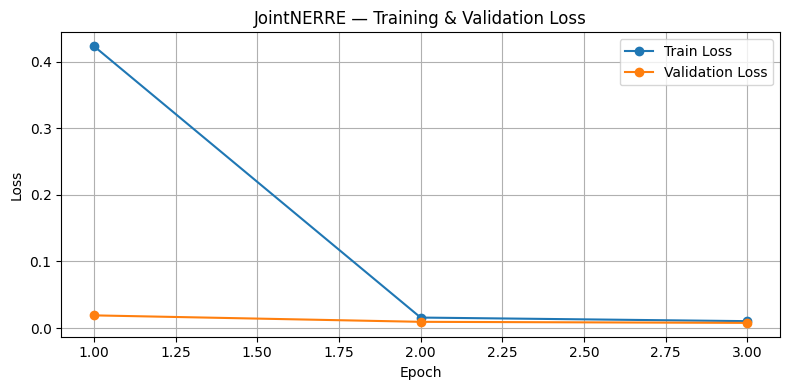

Saved: C:\Users\nivsa\Generation of Synthetic Training Data\embedded\models\loss_curve.png


In [4]:
import matplotlib.pyplot as plt

epochs     = [1, 2, 3]
train_loss = [0.4237, 0.0157, 0.0103]
val_loss   = [0.0190, 0.0093, 0.0077]

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss,   marker='o', label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("JointNERRE — Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = r"C:\Users\nivsa\Generation of Synthetic Training Data\embedded\models\loss_curve.png"
plt.savefig(save_path, dpi=150)
plt.show()
print(f"Saved: {save_path}")

In [ ]:
שלב החיזוי

לקחית PDF אמיתי, להמיר אותו לHTML ואז הפעלת המודל המאומן

In [2]:
print(5)

5


In [1]:
%%writefile "C:/Users/nivsa/Generation of Synthetic Training Data/embedded/extraction_engine/pdf_inference_pipeline.py"

"""
pdf_inference_pipeline.py  (v3 — all fixes applied)
=====================================================

Pipeline מלא:
    PDF → HTML גולמי → סינון עמודים → ניקוי טקסט → Preprocessor → Aligner → מודל → JSON

תיקונים בגרסה זו (על בסיס ביקורת על IRF740A / 91051):
  תיקון 1 — סינון עמודים: רק עמודים עם טבלאות חשמליות עוברים לשלבים הבאים
  תיקון 2 — הרחבת ELECTRICAL_HEADER_KEYWORDS: זיהוי THERMAL ו-SYMBOL
  תיקון 3 — הסרת טקסט הפוך מגרפים: "ecruo", "S-ot-niar" וכד'
  תיקון 4 — הסרת עמודי disclaimer משפטי אוטומטית
  תיקון 5 — Aligner עם tables_only=True: רק טוקנים מטבלאות
  תיקון 6 — סינון פרמטרים לא-תקינים מהפלט הסופי
"""

from __future__ import annotations

import json
import logging
import re
import shutil
import sys
import html as html_module
import traceback
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

from bs4 import BeautifulSoup, Tag

logging.basicConfig(
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
    level=logging.INFO,
)
log = logging.getLogger(__name__)


# =============================================================================
# נתיבים — שנה כאן בלבד
# =============================================================================

BASE        = r"C:\Users\nivsa\Generation of Synthetic Training Data\embedded"
INPUT_DIR   = Path(BASE) / "example_datasheets"
OUTPUT_DIR  = Path(BASE) / "output_results"
ALIGNER_DIR = Path(BASE) / "extraction_engine"
MODEL_PATH  = Path(BASE) / "models" / "checkpoints"

# "auto" | "trained" | "base" | "dummy"
NER_MODE = "auto"


# =============================================================================
# שלב 1 — PDF → HTML גולמי  (pdfplumber)
# =============================================================================

class PDFConverter:
    """ממיר PDF ל-HTML עם <table> מדויק לכל טבלה בעמוד."""

    _TABLE_SETTINGS = {
        "vertical_strategy":   "lines",
        "horizontal_strategy": "lines",
        "snap_tolerance":      5,
        "join_tolerance":      3,
        "edge_min_length":     10,
    }
    _TABLE_SETTINGS_FALLBACK = {
        "vertical_strategy":   "text",
        "horizontal_strategy": "text",
        "snap_tolerance":      3,
    }

    def convert(self, pdf_path: Path) -> str:
        try:
            import pdfplumber
        except ImportError:
            raise ImportError("pip install pdfplumber")

        html_parts = [
            "<!DOCTYPE html>",
            "<html><head><meta charset='UTF-8'></head><body>",
        ]

        with pdfplumber.open(str(pdf_path)) as pdf:
            for page_num, page in enumerate(pdf.pages, start=1):
                html_parts.append(f"<div class='page' data-page='{page_num}'>")

                table_objs = page.find_tables(self._TABLE_SETTINGS)
                if not table_objs:
                    table_objs = page.find_tables(self._TABLE_SETTINGS_FALLBACK)

                table_bboxes = [t.bbox for t in table_objs]

                for tbl in table_objs:
                    data = tbl.extract()
                    if not data:
                        continue
                    html_parts.append("<table>")
                    for row_idx, row in enumerate(data):
                        tag = "th" if row_idx == 0 else "td"
                        html_parts.append("<tr>")
                        for cell in row:
                            html_parts.append(f"<{tag}>{self._clean(cell)}</{tag}>")
                        html_parts.append("</tr>")
                    html_parts.append("</table>")

                words = page.extract_words(x_tolerance=3, y_tolerance=3)
                non_tbl_words = [
                    w for w in words if not self._in_any_bbox(w, table_bboxes)
                ]
                if non_tbl_words:
                    for line in self._group_lines(non_tbl_words):
                        text = " ".join(self._clean(w["text"]) for w in line)
                        if text.strip():
                            html_parts.append(f"<p>{text}</p>")

                html_parts.append("</div>")

        html_parts.append("</body></html>")
        return "\n".join(html_parts)

    @staticmethod
    def _clean(text: Optional[str]) -> str:
        if text is None:
            return ""
        return html_module.escape(" ".join(str(text).split()))

    @staticmethod
    def _in_any_bbox(word: dict, bboxes: list) -> bool:
        cx = (word["x0"] + word["x1"]) / 2
        cy = (word["top"] + word["bottom"]) / 2
        return any(x0 <= cx <= x1 and top <= cy <= bot
                   for x0, top, x1, bot in bboxes)

    @staticmethod
    def _group_lines(words: list, y_tol: float = 5) -> list:
        if not words:
            return []
        words = sorted(words, key=lambda w: (w["top"], w["x0"]))
        lines, cur_line, cur_y = [], [words[0]], words[0]["top"]
        for w in words[1:]:
            if abs(w["top"] - cur_y) <= y_tol:
                cur_line.append(w)
            else:
                lines.append(sorted(cur_line, key=lambda x: x["x0"]))
                cur_line, cur_y = [w], w["top"]
        if cur_line:
            lines.append(sorted(cur_line, key=lambda x: x["x0"]))
        return lines


# =============================================================================
# תיקון 1 — סינון עמודים: רק עמודים עם טבלאות חשמליות
# תיקון 4 — הסרת עמודי disclaimer משפטי
# תיקון 3 — הסרת טקסט הפוך מגרפים
# =============================================================================

# מילות מפתח המעידות שעמוד מכיל טבלת מפרטים
_ELECTRICAL_PAGE_SIGNALS = {
    "min", "max", "typ", "unit", "units",
    "min.", "max.", "typ.",
    "parameter", "symbol",
    "specifications", "electrical", "thermal",
    "absolute maximum", "absolute max",
    "static", "dynamic",
    "drain", "gate", "source",           # מפרטי MOSFET ספציפיים
    "voltage", "current", "resistance",  # מילות מפתח כלליות
}

# ביטויים המעידים שעמוד הוא disclaimer משפטי — תיקון 4
_LEGAL_SIGNALS = [
    "legal disclaimer",
    "all product, product specifications",
    "subject to change without notice",
    "not designed for use in life-saving",
    "all rights reserved",
    "without limitation special",
    "warranties of fitness",
]

# רגקס לזיהוי מילה הפוכה: 4+ תווים אלפביתיים שנקראים כמילה אנגלית הפוכה — תיקון 3
# הקריטריון: המילה מכילה רק אותיות, אין בה ספרות, ואינה מילה אנגלית נפוצה
_ROTATED_WORD_RE = re.compile(r"^[a-z]{4,}$")

# מילים אנגליות נפוצות שלא נסנן אותן (False Positive guard)
_COMMON_WORDS = {
    "that", "this", "with", "from", "have", "been", "will", "they",
    "their", "when", "also", "more", "over", "than", "then", "some",
    "each", "such", "into", "only", "most", "both", "time", "very",
    "much", "well", "even", "back", "just", "data", "case", "gate",
    "test", "note", "peak", "rise", "fall", "turn", "body", "open",
    "area", "safe", "flat",
}


def _is_legal_page(page_div: Tag) -> bool:
    """
    תיקון 4: מזהה עמוד disclaimer משפטי לפי צבירת ביטויים אופייניים.
    דורש לפחות 2 ביטויים — מניעת False Positives.
    """
    text  = page_div.get_text().lower()
    count = sum(1 for sig in _LEGAL_SIGNALS if sig in text)
    return count >= 2


def _has_electrical_content(page_div: Tag) -> bool:
    """
    תיקון 1: בודק אם עמוד מכיל לפחות טבלה אחת עם מילת מפתח חשמלית.
    בודק גם טקסט כותרת הטבלה (super-header).
    """
    for table in page_div.find_all("table"):
        table_text = table.get_text().lower()
        if any(sig in table_text for sig in _ELECTRICAL_PAGE_SIGNALS):
            return True
    return False


def _is_rotated_word(word: str) -> bool:
    """
    תיקון 3: מזהה מילה בודדת כטקסט הפוך מגרף.
    קריטריונים: 4+ אותיות, לא מילה נפוצה, ולא מכילה ספרות.
    """
    w = word.lower().strip()
    if not _ROTATED_WORD_RE.match(w):
        return False
    if w in _COMMON_WORDS:
        return False
    return True


def _remove_rotated_text_from_page(page_div: Tag) -> None:
    """
    תיקון 3: מסיר פסקאות <p> שמרביתן מילים הפוכות מגרפים.
    קריטריון: >40% מהמילים בפסקה נראות כמילים הפוכות.
    """
    for p_tag in page_div.find_all("p"):
        text  = p_tag.get_text()
        words = [w for w in text.split() if len(w) >= 2]
        if not words:
            continue
        rotated_count = sum(1 for w in words if _is_rotated_word(w))
        ratio = rotated_count / len(words)
        if ratio > 0.4:
            p_tag.decompose()


def filter_html_pages(raw_html: str) -> Tuple[str, Dict]:
    """
    תיקון 1 + 3 + 4: מקבל HTML גולמי מ-pdfplumber ומחזיר HTML מסונן.

    מה שמוסר:
      - עמודי disclaimer משפטי (תיקון 4)
      - עמודים ללא תוכן חשמלי (תיקון 1)
      - פסקאות של טקסט הפוך מגרפים (תיקון 3)

    מחזיר (filtered_html, stats_dict).
    """
    soup  = BeautifulSoup(raw_html, "html.parser")
    pages = soup.find_all("div", class_="page")

    stats = {
        "total_pages":    len(pages),
        "legal_removed":  0,
        "no_elec_removed": 0,
        "kept_pages":     0,
        "rotated_paras_removed": 0,
    }

    kept_pages: List[Tag] = []

    for page in pages:
        # תיקון 4: הסר עמודי disclaimer
        if _is_legal_page(page):
            stats["legal_removed"] += 1
            log.debug(f"  דילוג עמוד {page.get('data-page','?')} — disclaimer משפטי")
            continue

        # תיקון 1: הסר עמודים ללא תוכן חשמלי
        if not _has_electrical_content(page):
            stats["no_elec_removed"] += 1
            log.debug(f"  דילוג עמוד {page.get('data-page','?')} — אין תוכן חשמלי")
            continue

        # תיקון 3: הסר פסקאות טקסט הפוך בתוך העמוד שנשמר
        paras_before = len(page.find_all("p"))
        _remove_rotated_text_from_page(page)
        paras_after  = len(page.find_all("p"))
        stats["rotated_paras_removed"] += paras_before - paras_after

        kept_pages.append(page)
        stats["kept_pages"] += 1

    if not kept_pages:
        log.warning("לא נשמר אף עמוד אחרי הסינון — מחזיר HTML מקורי")
        return raw_html, stats

    filtered_html = (
        "<!DOCTYPE html>\n"
        "<html><head><meta charset='UTF-8'></head><body>\n"
        + "\n".join(str(p) for p in kept_pages)
        + "\n</body></html>"
    )
    return filtered_html, stats


# =============================================================================
# תיקון 2 — Preprocessor עם ELECTRICAL_HEADER_KEYWORDS מורחב
# =============================================================================

# תיקון 2: הוסף "symbol", "sym", "thermal", "parameter", "param"
# כדי שטבלת THERMAL RESISTANCE תזוהה נכון
ELECTRICAL_HEADER_KEYWORDS = {
    # קיים
    "min", "max", "typ", "typical", "minimum", "maximum",
    "nom", "nominal", "unit", "units",
    "min.", "max.", "typ.", "nom.",
    "value", "rating", "limit",
    # תיקון 2 — חדש:
    "symbol", "sym", "sym.",
    "parameter", "param",
    "thermal",
    "testconditions", "conditions", "condition",
    "spec", "specs",
}

HEADER_ROLE_MAP: Dict[str, str] = {
    "parameter":      "PARAMETER",
    "param":          "PARAMETER",
    "testconditions": "CONDITION",
    "testcon":        "CONDITION",
    "conditions":     "CONDITION",
    "condition":      "CONDITION",
    "notes":          "CONDITION",
    "min":            "MIN",      "minimum":  "MIN",
    "max":            "MAX",      "maximum":  "MAX",
    "typ":            "TYP",      "typical":  "TYP",
    "nom":            "TYP",      "nominal":  "TYP",
    "value":          "MAX",      "rating":   "MAX",   "limit": "MAX",
    "unit":           "UNIT",     "units":    "UNIT",  "uom":   "UNIT",
    # תיקון 2 — חדש:
    "symbol":         "SYMBOL",   "sym":      "SYMBOL", "sym.": "SYMBOL",
}

_CID_RE      = re.compile(r"\(cid:\d+\)", re.IGNORECASE)
_SIGNED_NUM  = re.compile(
    r"[+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?(?:\s*%)?|±\s*(?:\d+\.?\d*|\.\d+)"
)
_SUB_TAIL_RE = re.compile(
    r"\b([A-Z]{1,3})\s*([=<>]+|[≤≥]+)\s*([^\s,;]+)\s+([A-Z]{1,3})\b"
)


def _pp_clean(text: str) -> str:
    text = _CID_RE.sub("", text).replace("\u2581", " ")
    return re.sub(r"[ \t]+", " ", text).strip()

def _split_runon(text: str) -> str:
    if not text or " " in text:
        return text
    spaced = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    return spaced.strip() if spaced != text else text

def _reassemble_sub(text: str) -> str:
    return _SUB_TAIL_RE.sub(
        lambda m: f"{m.group(1)}_{m.group(4)} {m.group(2)} {m.group(3)}", text
    )

def _norm_hdr(h: str) -> str:
    return h.lower().replace(" ", "").replace(".", "").strip()

def _build_roles(raw_headers: List[str]) -> List[Optional[str]]:
    n = len(raw_headers)
    roles: List[Optional[str]] = [None] * n
    i = 0
    while i < n:
        if i + 1 < n:
            combined = _norm_hdr(raw_headers[i] + raw_headers[i + 1])
            if combined in HEADER_ROLE_MAP:
                roles[i] = roles[i + 1] = HEADER_ROLE_MAP[combined]
                i += 2
                continue
        single = _norm_hdr(raw_headers[i])
        if single in HEADER_ROLE_MAP:
            roles[i] = HEADER_ROLE_MAP[single]
        i += 1
    return roles

def _is_electrical(raw_headers: List[str]) -> bool:
    return bool({_norm_hdr(h) for h in raw_headers} & ELECTRICAL_HEADER_KEYWORDS)


def _find_header_row_idx(rows: list) -> int:
    """
    מאתר את אינדקס שורת הכותרות האמיתית בטבלה.

    דפוסים נתמכים:
      1. Super-header: row[0] = כותרת סקציה ממוזגת, row[1] = עמודות אמיתיות
         (Vishay, Infineon, TI Abs Max)
      2. רגיל: row[0] הוא כבר שורת הכותרות
         (ON Semi, רוב הטבלאות)

    סורק עד 3 שורות. מחזיר 0 כ-fallback.
    """
    for i, row in enumerate(rows[:3]):
        cells = [c.get_text(strip=True) for c in row.find_all(["th", "td"])]
        if _is_electrical(cells):
            return i
    return 0


def _merge_header_table(
    header_table: Tag,
    data_tables:  List[Tag],
) -> Optional[Tag]:
    """
    דפוס ON Semi / Fairchild: טבלת כותרות נפרדת + טבלאות נתונים ללא כותרות.

    מזהה את הדפוס כאשר:
      - header_table מכילה בדיוק שורה אחת עם מילות מפתח חשמליות
      - data_tables[0] מכילה שורות נתונים שמספר עמודותיהן תואם לכותרות

    מחזיר Tag חדש עם הכותרות + כל שורות הנתונים,
    או None אם הדפוס לא מתאים.
    """
    hdr_rows = header_table.find_all("tr")
    if len(hdr_rows) != 1:
        return None

    hdr_cells = [c.get_text(strip=True) for c in hdr_rows[0].find_all(["th", "td"])]
    if not _is_electrical(hdr_cells):
        return None

    n_cols = len(hdr_cells)
    if n_cols < 3:
        return None

    # בדוק שהטבלה הבאה תואמת במספר עמודות (±1 כי לפעמים יש עמודת condition כפולה)
    if not data_tables:
        return None
    first_data_rows = data_tables[0].find_all("tr")
    if not first_data_rows:
        return None
    first_data_cols = len(first_data_rows[0].find_all(["th", "td"]))
    if abs(first_data_cols - n_cols) > 2:
        return None

    # בנה soup חדש: כותרת + כל שורות הנתונים מכל הטבלאות
    combined_html = "<table>\n<tr>" + "".join(
        f"<th>{html_module.escape(c)}</th>" for c in hdr_cells
    ) + "</tr>\n"

    for data_tbl in data_tables:
        for row in data_tbl.find_all("tr"):
            combined_html += str(row) + "\n"

    combined_html += "</table>"
    return BeautifulSoup(combined_html, "html.parser").find("table")


def _infer_roles_from_data(rows: List, n_cols: int) -> List[Optional[str]]:
    """
    דפוס TI / אחרים: שורת כותרות קיימת אבל col[0] ריק בכל שורות הנתונים.
    במקרה זה col[0] הוא בפועל עמודת SYMBOL/PARAMETER משנית שחסרה כותרת.

    בודק: האם col[0] ריק ב-80%+ משורות הנתונים?
    אם כן — מסיק שcol[0] הוא SYMBOL (לא נצטרך להגדיר role מפורש,
    אלא פשוט לא לתת לו role כדי שלא יפריע לPARAMETER בcol[1]).

    מחזיר dict עם correction שיש להחיל על roles הקיים.
    לא משנה את _build_roles, רק מסיר role שגוי מcol[0].
    """
    if not rows or n_cols < 2:
        return []

    col0_empty = 0
    total = 0
    for row in rows[:10]:
        cells = row.find_all(["td", "th"])
        if not cells:
            continue
        total += 1
        val = cells[0].get_text(strip=True) if cells else ""
        if len(val) < 12:   # קצר מאוד = likely symbol fragment or empty
            col0_empty += 1

    if total > 0 and col0_empty / total >= 0.7:
        return [0]   # רשימת אינדקסים של עמודות שצריך לשנות ל-SYMBOL
    return []


def _split_vals(cell: str) -> List[str]:
    """
    מפצל תא לרשימת ערכים מספריים.

    תומך ב:
      "3.0"          → ['3.0']            (ערך יחיד)
      "-1 1"         → ['-1', '1']        (min/max סימטרי)
      "240 450 750"  → ['240','450','750'] (min/typ/max)
      "−55 to +175"  → ['-55', '175']     (טווח)
    """
    cell = cell.strip()
    if not cell:
        return []
    tokens = [m.group().strip() for m in _SIGNED_NUM.finditer(cell)
              if re.search(r"\d", m.group())]
    return tokens if tokens else [cell]


def _assign_vals(
    nums:  List[str],
    role:  str,
) -> Tuple[Optional[str], Optional[str], Optional[str]]:
    """
    ממפה רשימת ערכים מספריים ל-(min, typ, max) לפי ה-role וכמות הערכים.

    1 ערך  → לפי role (MIN/TYP/MAX)
    2 ערכים → min=ראשון, max=אחרון  (ספציפיקציות סימטריות כמו -1 / +1)
    3 ערכים → min, typ, max          (TI: 240 450 750 mA)
    4+ ערכים → min=ראשון, max=אחרון (טווחים מורכבים)
    """
    n = len(nums)
    if n == 0:
        return None, None, None
    if n == 1:
        v = nums[0]
        if role == "MIN":  return v,    None, None
        if role == "MAX":  return None, None, v
        if role == "TYP":  return None, v,    None
        return None, v, None       # fallback → typ
    if n == 2:
        return nums[0], None, nums[1]
    if n == 3:
        return nums[0], nums[1], nums[2]
    # 4+: min/max בלבד
    return nums[0], None, nums[-1]


def _pick(nums: List[str], role: str) -> Optional[str]:
    """Legacy helper — משמש עדיין לCONDITION / SYMBOL."""
    if not nums:        return None
    if len(nums) == 1:  return nums[0]
    if role == "MIN":   return nums[0]
    if role == "MAX":   return nums[-1]
    return nums[len(nums) // 2]


class _TableCleaner:
    """מנקה טבלה אחת ומחזיר HTML + רשימת פרמטרים."""

    def __init__(self, table: Tag):
        self.table = table
        self.rows  = table.find_all("tr")

    def process(self) -> Tuple[str, List[Dict]]:
        if not self.rows:
            return str(self.table), []

        hdr_idx = _find_header_row_idx(self.rows)

        raw_headers = [
            c.get_text(strip=True)
            for c in self.rows[hdr_idx].find_all(["th", "td"])
        ]

        if not _is_electrical(raw_headers):
            for node in self.table.find_all(string=True):
                node.replace_with(_pp_clean(str(node)))
            return str(self.table), []

        n_cols = len(raw_headers)
        roles  = _build_roles(raw_headers)

        # ── כוללני: זיהוי עמודה שחסרה כותרת אבל מכילה symbol/fragment ──
        # (דפוס TI: col[0] ריק ב-70%+ משורות הנתונים)
        # כשמזוהה — col[0] מקבל role=SYMBOL אם אין לו role, כדי שלא
        # יפריע לPARAMETER ב-col[1] וגם לא יאבד לחלוטין.
        data_rows = self.rows[hdr_idx + 1:]
        empty_col_indices = _infer_roles_from_data(data_rows, n_cols)
        for col_idx in empty_col_indices:
            if col_idx < len(roles) and roles[col_idx] is None:
                roles[col_idx] = "SYMBOL"

        # שורות super-header לפני הכותרות
        out_rows = []
        for i in range(hdr_idx):
            cells = [c.get_text(strip=True)
                     for c in self.rows[i].find_all(["th", "td"])]
            out_rows.append(
                "<tr>" + "".join(
                    f"<th colspan='{n_cols}'>{html_module.escape(_pp_clean(cells[0]))}</th>"
                    if len(cells) == 1 or all(c == "" for c in cells[1:])
                    else f"<th>{html_module.escape(_pp_clean(c))}</th>"
                    for c in cells
                ) + "</tr>"
            )

        out_rows.append("<tr>" + "".join(
            f"<th>{html_module.escape(_pp_clean(h))}</th>" for h in raw_headers
        ) + "</tr>")

        parameters      = []
        last_param: str = ""
        last_unit:  str = ""

        for row in data_rows:
            cells      = row.find_all(["td", "th"])
            cell_texts = [
                _pp_clean(cells[i].get_text(strip=True)) if i < len(cells) else ""
                for i in range(n_cols)
            ]

            role_text: Dict[str, str] = {}
            for idx, role in enumerate(roles):
                if not role or not cell_texts[idx]:
                    continue
                if role == "SYMBOL" and role in role_text:
                    continue
                role_text[role] = (
                    (role_text[role] + " " + cell_texts[idx]).strip()
                    if role in role_text else cell_texts[idx]
                )

            param_raw = role_text.get("PARAMETER", "")
            param     = _split_runon(param_raw) if param_raw else ""
            if param:
                last_param = param
            effective = last_param

            cond = _reassemble_sub(role_text.get("CONDITION", ""))

            # ── כוללני: _assign_vals מטפל ב-1/2/3+ ערכים בתא ──────────
            min_v = typ_v = max_v = None

            for value_role in ("MIN", "TYP", "MAX"):
                raw = role_text.get(value_role, "")
                if not raw:
                    continue
                nums = _split_vals(raw)
                mn, tp, mx = _assign_vals(nums, value_role)
                if mn is not None and min_v is None: min_v = mn
                if tp is not None and typ_v is None: typ_v = tp
                if mx is not None and max_v is None: max_v = mx

            unit_raw = role_text.get("UNIT", "")
            if unit_raw:
                last_unit = unit_raw
            unit = last_unit

            td_parts, emitted = [], set()
            for idx, role in enumerate(roles):
                if role is None:
                    td_parts.append(f"<td>{html_module.escape(cell_texts[idx])}</td>")
                    continue
                if role in emitted:
                    td_parts.append("<td></td>")
                    continue
                emitted.add(role)
                val_map = {
                    "PARAMETER": param,   "CONDITION": cond,
                    "MIN":       min_v,   "TYP":       typ_v,
                    "MAX":       max_v,   "UNIT":      unit,
                    "SYMBOL":    role_text.get("SYMBOL", ""),
                }
                v = val_map.get(role, cell_texts[idx])
                td_parts.append(
                    f"<td>{html_module.escape(v)}</td>" if v else "<td>—</td>"
                )
            out_rows.append("<tr>" + "".join(td_parts) + "</tr>")

            has_values = any([min_v, typ_v, max_v])
            if not effective and not has_values and not cond:
                continue
            parameters.append({
                "parameter": effective,
                "min":       min_v,
                "typ":       typ_v,
                "max":       max_v,
                "unit":      unit or None,
                "condition": cond or None,
            })

        return "<table>\n" + "\n".join(out_rows) + "\n</table>", parameters


class DatasheetHTMLPreprocessor:
    """שלב 2 — מנקה HTML מסונן ומחזיר HTML נקי."""

    def process(self, filtered_html: str) -> Tuple[str, List[Dict], Dict]:
        n_cid        = len(_CID_RE.findall(filtered_html))
        filtered_html = _CID_RE.sub("", filtered_html).replace("\u2581", " ")

        soup       = BeautifulSoup(filtered_html, "html.parser")
        all_params = []

        # ── כוללני: מיזוג header-table + data-tables (דפוס ON Semi/Fairchild) ──
        # מזהה טבלת כותרות בודדת (שורה אחת עם מילות מפתח) שאחריה
        # מספר טבלאות נתונים ללא כותרות, ומאחד אותן לטבלה אחת.
        all_tables = soup.find_all("table")
        merged_tables: set = set()   # id() של טבלאות שכבר עובדו

        for i, table in enumerate(all_tables):
            if id(table) in merged_tables:
                continue
            rows = table.find_all("tr")
            if len(rows) != 1:
                continue
            hdr_cells = [c.get_text(strip=True) for c in rows[0].find_all(["th","td"])]
            if not _is_electrical(hdr_cells):
                continue

            # נסה לאסוף טבלאות נתונים עוקבות (עד 8) שאין להן כותרות
            subsequent: List[Tag] = []
            for j in range(i + 1, min(i + 9, len(all_tables))):
                nxt = all_tables[j]
                if id(nxt) in merged_tables:
                    break
                nxt_rows = nxt.find_all("tr")
                if not nxt_rows:
                    break
                nxt_r0 = [c.get_text(strip=True) for c in nxt_rows[0].find_all(["th","td"])]
                # עצור אם הטבלה הבאה מכילה כותרות בעצמה
                if _is_electrical(nxt_r0):
                    break
                subsequent.append(nxt)

            if not subsequent:
                continue

            merged = _merge_header_table(table, subsequent)
            if merged is None:
                continue

            # החלף את טבלת הכותרות ב-merged, הסר את הנתונים המקוריים
            table.replace_with(merged)
            for s in subsequent:
                merged_tables.add(id(s))
                s.decompose()

        for table in soup.find_all("table"):
            cleaner = _TableCleaner(table)
            clean_html, params = cleaner.process()
            if params:
                all_params.extend(params)
                table.replace_with(BeautifulSoup(clean_html, "html.parser"))

        for node in soup.find_all(string=True):
            orig = str(node)
            c    = _pp_clean(orig)
            if c != orig:
                node.replace_with(c)

        diag = {"cid_removed": n_cid, "params_found": len(all_params)}
        return str(soup), all_params, diag


# =============================================================================
# תיקון 5 — Aligner עם tables_only=True
# =============================================================================

def _parameters_to_relations(parameters: List[Dict]) -> List[Dict]:
    """
    ממיר פרמטרים שחולצו ע"י ה-Preprocessor ל-relation triples.
    הפורמט זהה לפורמט שה-aligner._add_relations() מצפה לקבל —
    כך ניתן להשתמש בתשתית הקיימת ל-alignment לטוקנים.

    לכל פרמטר נוצרות עד 5 triples:
      has_min / has_typ / has_max / has_unit / has_condition
    """
    predicate_map = {
        "min":       "has_min",
        "typ":       "has_typ",
        "max":       "has_max",
        "unit":      "has_unit",
        "condition": "has_condition",
    }
    triples: List[Dict] = []
    for p in parameters:
        subject = (p.get("parameter") or "").strip()
        if not subject:
            continue
        for key, predicate in predicate_map.items():
            obj = p.get(key)
            if not obj:
                continue
            obj_str = str(obj).strip()
            # דלג על ערכי placeholder ("-", "—") וערכים ריקים
            if not obj_str or obj_str in ("-", "—", "–"):
                continue
            # דלג על self-referential (subject == object)
            if obj_str.lower() == subject.lower():
                continue
            triples.append({
                "subject":   subject,
                "predicate": predicate,
                "object":    obj_str,
            })
    return triples


def run_aligner(clean_html: str, aligner_dir: Path) -> List[Dict]:
    """
    תיקון 5: מריץ את PreprocessingEngine עם קלט מצומצם לטבלאות בלבד.
    מחלץ את תגיות <table> מה-HTML ומעביר רק אותן ל-Aligner.

    הערה: לא מעביר relations כאן — ה-guard ב-_add_relations של ה-aligner
    דורש ner_tags != O, וב-inference הכל O. ה-alignment מתבצע בנפרד
    אחרי הרצת המודל, דרך _align_relations_inference().
    """
    aligner_str = str(aligner_dir)
    if aligner_str not in sys.path:
        sys.path.insert(0, aligner_str)

    from aligner import PreprocessingEngine  # noqa: E402

    soup   = BeautifulSoup(clean_html, "html.parser")
    tables = soup.find_all("table")

    if tables:
        tables_only_html = (
            "<html><head><meta charset='UTF-8'></head><body>\n"
            + "\n".join(str(t) for t in tables)
            + "\n</body></html>"
        )
    else:
        log.warning("        לא נמצאו טבלאות ב-HTML הנקי — מעביר HTML מלא ל-Aligner")
        tables_only_html = clean_html

    engine  = PreprocessingEngine(tokenizer=None)
    samples = engine.process(tables_only_html, jsonl_relations=None)
    return samples


def _align_relations_inference(
    samples:   List[Dict],
    relations: List[Dict],
) -> List[Dict]:
    """
    מיישר relation triples לטוקנים — גרסת inference בלבד.

    ההבדל מ-aligner._add_relations():
      - ה-guard שבודק ner_tags != O הוסר.
        ב-inference ner_tags הם תמיד O (אין data-label spans),
        אז הguard היה חוסם את כל ה-relations.
      - כל שאר הלוגיקה (phrase matching, trim_span, dedup) זהה.

    לא נוגעים ב-aligner.py — ה-guard שם נכון לאימון ולא ישונה.
    """
    import re as _re

    if not relations:
        return samples

    # ── normalize: זהה ל-aligner._add_relations ──────────────────────
    from aligner import PreprocessingEngine as _PE
    _eng = _PE.__new__(_PE)  # instance ללא __init__ לגישה ל-methods

    def _normalize(s: str) -> str:
        s = _eng._clean_artifacts(s)
        return _re.sub(r'[^a-z0-9]', '', s.lower())

    _NOISE = {'\n', '\t', '—', '-', '–', '', ' '}

    def _trim(indices: List[int], toks: List[str]) -> List[int]:
        start = 0
        while start < len(indices) and toks[indices[start]] in _NOISE:
            start += 1
        end = len(indices)
        while end > start and toks[indices[end - 1]] in _NOISE:
            end -= 1
        return indices[start:end] if start < end else indices

    # ── בנה phrase index על כל ה-samples ────────────────────────────
    phrase_index: Dict[str, List[Tuple[int, List[int]]]] = {}

    for si, sample in enumerate(samples):
        toks      = sample['tokens']
        max_ngram = min(10, len(toks))
        for n in range(1, max_ngram + 1):
            for i in range(len(toks) - n + 1):
                span_toks = toks[i:i + n]
                if not any(t not in _NOISE for t in span_toks):
                    continue
                phrase_norm = _normalize(' '.join(span_toks))
                if not phrase_norm:
                    continue
                phrase_index.setdefault(phrase_norm, []).append(
                    (si, list(range(i, i + n)))
                )

    # ── יישור כל triple ──────────────────────────────────────────────
    for rel in relations:
        subj = str(rel.get('subject', '')).strip()
        pred = rel.get('predicate', '')
        obj  = str(rel.get('object',  '')).strip()

        if not subj or not obj or subj == obj:
            continue

        subj_norm = _normalize(subj)
        obj_norm  = _normalize(obj)

        if subj_norm == obj_norm:
            continue

        for sample_idx, raw_subj_idx in phrase_index.get(subj_norm, []):
            toks = samples[sample_idx]['tokens']

            subj_indices = _trim(raw_subj_idx, toks)
            if not subj_indices:
                continue

            obj_matches = [
                (idx, idxs)
                for idx, idxs in phrase_index.get(obj_norm, [])
                if idx == sample_idx
            ]
            if not obj_matches:
                continue

            subj_end = subj_indices[-1]
            _, raw_obj_idx = min(
                obj_matches, key=lambda x: abs(x[1][0] - subj_end)
            )
            obj_indices = _trim(raw_obj_idx, toks)
            if not obj_indices or subj_indices == obj_indices:
                continue

            new_rel = {
                'head': subj_indices,
                'type': pred,
                'tail': obj_indices,
            }
            if new_rel not in samples[sample_idx]['relations']:
                samples[sample_idx]['relations'].append(new_rel)

    return samples


# =============================================================================
# שלב 4 — Tokens → NER predictions  (Model)
# =============================================================================

class NERModel:
    LABEL_LIST = [
        "O",
        "B-PARAMETER", "I-PARAMETER",
        "B-MIN",       "I-MIN",
        "B-MAX",       "I-MAX",
        "B-TYP",       "I-TYP",
        "B-UNIT",      "I-UNIT",
        "B-CONDITION", "I-CONDITION",
        "B-VALUE",     "I-VALUE",
    ]
    BASE_MODEL = "microsoft/deberta-v3-base"

    def __init__(self, model_path: Path, mode: str = "auto"):
        self.model_path = model_path
        self.mode       = mode
        self.tokenizer  = None
        self.model      = None
        self.id2label: Dict[int, str] = {i: l for i, l in enumerate(self.LABEL_LIST)}
        self.device     = None
        self._load()

    def _load(self):
        if self.mode == "dummy":
            log.warning("Dummy mode — ללא מודל.")
            return

        try:
            from transformers import AutoTokenizer, AutoModelForTokenClassification
            import torch
        except ImportError:
            raise ImportError("pip install transformers torch")

        source = self._resolve_source()

        log.info(f"טוען tokenizer מ-{self.BASE_MODEL}…")
        self.tokenizer = AutoTokenizer.from_pretrained(self.BASE_MODEL, use_fast=False)

        log.info(f"טוען מודל מ-{source}…")
        if source == self.BASE_MODEL:
            from transformers import DebertaV2Config, DebertaV2ForTokenClassification
            label2id = {l: i for i, l in enumerate(self.LABEL_LIST)}
            cfg = DebertaV2Config.from_pretrained(
                self.BASE_MODEL,
                num_labels=len(self.LABEL_LIST),
                id2label=self.id2label, label2id=label2id,
            )
            self.model = DebertaV2ForTokenClassification.from_pretrained(
                self.BASE_MODEL, config=cfg, ignore_mismatched_sizes=True,
            )
            log.warning("נטען מודל בסיסי (לא מאומן) — predictions אינן אמינות.")
        else:
            self.model = AutoModelForTokenClassification.from_pretrained(source)
            if self.model.config.id2label:
                self.id2label = self.model.config.id2label
            log.info("checkpoint מאומן נטען.")

        self.model.eval()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        log.info(f"device={self.device}")

    def _resolve_source(self) -> str:
        if self.mode == "base":
            return self.BASE_MODEL
        cfg_path = self.model_path / "config.json"
        if not self.model_path.exists() or not cfg_path.exists():
            if self.mode == "trained":
                raise FileNotFoundError(f"checkpoint לא נמצא: {self.model_path}")
            log.warning("checkpoint לא נמצא — fallback למודל בסיסי.")
            return self.BASE_MODEL
        try:
            cfg = json.loads(cfg_path.read_text(encoding="utf-8"))
            if "model_type" not in cfg:
                raise ValueError("חסר model_type")
            return str(self.model_path)
        except Exception as e:
            if self.mode == "trained":
                raise
            log.warning(f"config.json לא תקין ({e}) — fallback.")
            return self.BASE_MODEL

    def predict(self, samples: List[Dict]) -> List[Dict]:
        if self.mode == "dummy" or self.model is None:
            for s in samples:
                s["pred_tags"] = ["O"] * len(s["tokens"])
            return samples

        import torch

        for sample in samples:
            tokens = sample["tokens"]
            if not tokens:
                sample["pred_tags"] = []
                continue

            enc = self.tokenizer(
                tokens,
                is_split_into_words=True,
                return_tensors="pt",
                truncation=True,
                max_length=512,
            )
            enc_gpu = {k: v.to(self.device) for k, v in enc.items()}

            with torch.no_grad():
                logits = self.model(**enc_gpu).logits

            pred_ids = logits.argmax(-1)[0].tolist()
            word_ids = enc.word_ids()   # CPU encoding — לא tensor

            pred_tags = []
            prev_wid  = None
            for pid, wid in zip(pred_ids, word_ids):
                if wid is None or wid == prev_wid:
                    continue
                pred_tags.append(self.id2label.get(pid, "O"))
                prev_wid = wid

            pred_tags = pred_tags[:len(tokens)]
            pred_tags += ["O"] * (len(tokens) - len(pred_tags))
            sample["pred_tags"] = pred_tags

        return samples


# =============================================================================
# שלב 5 — pred_tags → JSON מובנה
# תיקון 6 — סינון פרמטרים לא-תקינים
# =============================================================================

# תיקון 6: תבניות של parameter לא-תקין
_INVALID_PARAM_RE = re.compile(
    r"^[\s\n\t\r.,;:!?(){}[\]<>|/\\\"'`~@#$%^&*+=]+$"  # רק סימני פיסוק
)

# תיקון 6: אורך מינימלי/מקסימלי לפרמטר תקין
_PARAM_MIN_LEN = 2
_PARAM_MAX_LEN = 120


def _is_valid_parameter(param: Dict) -> bool:
    """
    תיקון 6: פילטר פרמטרים לא-תקינים מהפלט.

    פרמטר לא-תקין הוא אחד מהבאים:
      - שם ריק, רק whitespace, או רק סימני פיסוק
      - שם קצר מ-2 תווים או ארוך מ-120 (סבירות גבוהה שזה טקסט שגוי)
      - אין אף ערך (min/typ/max כולם None)
      - הערך מכיל newlines (סימן לטקסט גולמי שנכנס בטעות)
    """
    name = param.get("parameter", "")

    # שם ריק או רק whitespace
    if not name or not name.strip():
        return False

    # רק סימני פיסוק
    if _INVALID_PARAM_RE.match(name.strip()):
        return False

    # אורך לא סביר
    if len(name.strip()) < _PARAM_MIN_LEN or len(name.strip()) > _PARAM_MAX_LEN:
        return False

    # newline בשם (סימן לטקסט גולמי)
    if "\n" in name or "\r" in name:
        return False

    # אין אף ערך
    has_value = any(
        param.get(k) and str(param[k]).strip()
        for k in ("min", "typ", "max")
    )
    if not has_value:
        return False

    # ערך מכיל newline (טקסט גולמי)
    for key in ("min", "typ", "max", "unit"):
        v = param.get(key)
        if v and ("\n" in str(v) or len(str(v)) > 50):
            return False

    return True


def _label_to_key(label: str) -> Optional[str]:
    return {
        "PARAMETER": "parameter",
        "MIN":       "min",
        "TYP":       "typ",
        "MAX":       "max",
        "UNIT":      "unit",
        "CONDITION": "condition",
        "VALUE":     "max",
    }.get(label)


def _fill(current: Dict, label: str, tok: str):
    key = _label_to_key(label)
    if key and current.get(key) is None:
        current[key] = tok


def samples_to_parameters(samples: List[Dict]) -> List[Dict]:
    """
    ממיר samples (tokens + pred_tags) לרשימת פרמטרים.
    תיקון 6: מסנן פרמטרים לא-תקינים בסוף.
    """
    parameters: List[Dict] = []
    current: Optional[Dict] = None

    for sample in samples:
        tokens    = sample["tokens"]
        pred_tags = sample.get("pred_tags", ["O"] * len(tokens))

        for tok, tag in zip(tokens, pred_tags):
            if tag == "O":
                continue

            bio, label = tag.split("-", 1) if "-" in tag else ("O", "O")

            if bio == "B":
                if label == "PARAMETER":
                    if current and any(current.get(k) for k in ("min","typ","max")):
                        parameters.append(current)
                    current = {"parameter": tok, "min": None, "typ": None,
                               "max": None, "unit": None, "condition": None}
                elif current:
                    _fill(current, label, tok)

            elif bio == "I" and current:
                key = _label_to_key(label)
                if key == "parameter":
                    current["parameter"] = current["parameter"] + " " + tok
                elif key and current.get(key) is not None:
                    current[key] = current[key] + " " + tok

    if current and any(current.get(k) for k in ("min","typ","max")):
        parameters.append(current)

    # תיקון 6: סנן פרמטרים לא-תקינים
    before_filter = len(parameters)
    parameters    = [p for p in parameters if _is_valid_parameter(p)]
    after_filter  = len(parameters)

    if before_filter != after_filter:
        log.info(f"        סינון פלט: {before_filter} → {after_filter} פרמטרים "
                 f"(הוסרו {before_filter - after_filter} לא-תקינים)")

    return parameters


# =============================================================================
# Pipeline מלא — מחבר את כל השלבים
# =============================================================================

class PDFInferencePipeline:

    def __init__(
        self,
        input_dir:   Path,
        output_dir:  Path,
        aligner_dir: Path,
        model_path:  Path,
        ner_mode:    str = "auto",
    ):
        self.input_dir   = input_dir
        self.output_dir  = output_dir
        self.aligner_dir = aligner_dir

        log.info("מאתחל PDFConverter…")
        self.converter = PDFConverter()

        log.info("מאתחל DatasheetHTMLPreprocessor…")
        self.preprocessor = DatasheetHTMLPreprocessor()

        log.info("מאתחל NERModel…")
        self.ner = NERModel(model_path=model_path, mode=ner_mode)

    def run(self):
        self.output_dir.mkdir(parents=True, exist_ok=True)
        pdf_files = sorted(self.input_dir.glob("*.pdf"))
        if not pdf_files:
            log.warning(f"לא נמצאו PDFs ב-{self.input_dir}")
            return

        log.info(f"\n{'='*60}")
        log.info(f"מעבד {len(pdf_files)} PDFs → {self.output_dir}")
        log.info(f"{'='*60}\n")

        summary = {"ok": 0, "failed": 0, "files": []}
        for i, pdf_path in enumerate(pdf_files, 1):
            log.info(f"[{i}/{len(pdf_files)}] {pdf_path.name}")
            try:
                out_json = self._process_one(pdf_path)
                summary["ok"] += 1
                summary["files"].append(str(out_json))
            except Exception:
                log.error(traceback.format_exc())
                summary["failed"] += 1

        log.info(f"\n{'='*60}")
        log.info(f"הושלם: {summary['ok']} הצליחו | {summary['failed']} נכשלו")
        (self.output_dir / "_summary.json").write_text(
            json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
        )

    def _process_one(self, pdf_path: Path) -> Path:
        stem     = pdf_path.stem
        file_dir = self.output_dir / stem
        file_dir.mkdir(exist_ok=True)

        shutil.copy2(str(pdf_path), str(file_dir / pdf_path.name))

        # ── שלב 1: PDF → HTML גולמי ───────────────────────────────────
        log.info(f"  [1/5] PDF → HTML גולמי…")
        raw_html = self.converter.convert(pdf_path)
        (file_dir / f"{stem}.raw.html").write_text(raw_html, encoding="utf-8")
        log.info(f"        {len(raw_html)//1024}KB")

        # ── תיקונים 1+3+4: סינון עמודים ──────────────────────────────
        log.info(f"  [2/5] סינון עמודים…")
        filtered_html, filter_stats = filter_html_pages(raw_html)
        (file_dir / f"{stem}.filtered.html").write_text(filtered_html, encoding="utf-8")
        log.info(f"        נשמרו {filter_stats['kept_pages']}/{filter_stats['total_pages']} עמודים "
                 f"| legal={filter_stats['legal_removed']} "
                 f"| no_elec={filter_stats['no_elec_removed']} "
                 f"| rotated_paras={filter_stats['rotated_paras_removed']}")

        # ── תיקון 2: Preprocessor עם keywords מורחב ──────────────────
        log.info(f"  [3/5] Preprocessor…")
        clean_html, params_pp, diag = self.preprocessor.process(filtered_html)
        (file_dir / f"{stem}.clean.html").write_text(clean_html, encoding="utf-8")
        log.info(f"        cid={diag['cid_removed']}  params_preprocessor={diag['params_found']}")

        # ── תיקון 5: Aligner עם tables_only ──────────────────────────
        log.info(f"  [4/5] Aligner (tables only)…")
        samples      = run_aligner(clean_html, self.aligner_dir)
        total_tokens = sum(len(s["tokens"]) for s in samples)
        log.info(f"        windows={len(samples)}  tokens={total_tokens}")

        # ── NER + תיקון 6: סינון פלט ──────────────────────────────────
        log.info(f"  [5/5] NER + יישור relations…")
        samples_pred = self.ner.predict(samples)
        parameters   = samples_to_parameters(samples_pred)
        log.info(f"        {len(parameters)} פרמטרים תקינים חולצו")

        # ── יישור relations לטוקנים (אחרי המודל, ללא guard) ──────────
        pp_relations = _parameters_to_relations(params_pp)
        samples_with_rels = _align_relations_inference(samples_pred, pp_relations)
        total_rels = sum(len(s["relations"]) for s in samples_with_rels)
        log.info(f"        {len(pp_relations)} triples → {total_rels} aligned relations")

        result = {
            "source_pdf":          pdf_path.name,
            "parameters":          parameters,
            "total_found":         len(parameters),
            "relations":           pp_relations,
            "aligned_samples":     [
                {
                    "id":        s["id"],
                    "tokens":    s["tokens"],
                    "ner_tags":  s.get("pred_tags", []),
                    "relations": s.get("relations", []),
                }
                for s in samples_with_rels
                if s.get("relations")
            ],
            "preprocessor_params": params_pp,
            "filter_stats":        filter_stats,
            "diagnostics":         diag,
        }
        json_path = file_dir / f"{stem}.json"
        json_path.write_text(
            json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8"
        )
        log.info(f"  → {file_dir}\n")
        return json_path


# =============================================================================
# Entry point
# =============================================================================

if __name__ == "__main__":
    pipeline = PDFInferencePipeline(
        input_dir   = INPUT_DIR,
        output_dir  = OUTPUT_DIR,
        aligner_dir = ALIGNER_DIR,
        model_path  = MODEL_PATH,
        ner_mode    = NER_MODE,
    )
    pipeline.run()

Writing C:/Users/nivsa/Generation of Synthetic Training Data/embedded/extraction_engine/pdf_inference_pipeline.py


In [1]:
import torch
import torch.nn as nn
import re
from transformers import DebertaV2Model, DebertaV2TokenizerFast

# ==========================================
# 1. מילונים (מעודכן ומיושר ב-100% לאימון)
# ==========================================
NER_LABEL2ID = {
    "O": 0,
    "B-PARAMETER": 1, "I-PARAMETER": 2,
    "B-VALUE":     3, "I-VALUE":     4,
    "B-MIN":       5, "I-MIN":       6,  
    "B-MAX":       7, "I-MAX":       8,  
    "B-TYP":       9, "I-TYP":       10,
    "B-UNIT":     11, "I-UNIT":      12,
    "B-CONDITION":13, "I-CONDITION": 14,
}
NER_ID2LABEL = {v: k for k, v in NER_LABEL2ID.items()}

# ==========================================
# 2. מודל
# ==========================================
class JointNERRE(nn.Module):
    def __init__(self, model_name, num_ner_labels, num_rel_labels=7, dropout=0.1):
        super().__init__()
        self.encoder     = DebertaV2Model.from_pretrained(model_name)
        hidden_size      = self.encoder.config.hidden_size
        self.ner_dropout = nn.Dropout(dropout)
        self.ner_head    = nn.Linear(hidden_size, num_ner_labels)
        # נדרש כדי לטעון את המשקולות, גם אם לא מנבאים יחסים כרגע
        self.re_dropout  = nn.Dropout(dropout)
        self.re_head     = nn.Linear(hidden_size * 2, num_rel_labels)

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        sequence_output = outputs.last_hidden_state.float()
        ner_logits = self.ner_head(self.ner_dropout(sequence_output))
        return ner_logits

# ==========================================
# 3. נרמול טקסט (Pipeline Consistency!)
# פונקציה זהה לחלוטין לזו שב-aligner.py
# ==========================================
# הביטוי הרגולרי המדויק מתוך _tokenize_simple
TOKENIZE_PATTERN = re.compile(
    r'(\t|\n)'                                        # 1. structural
    r'|([+-]?(?:\d+\.?\d*|\.\d+)[eE][+-]?\d+)'        # 2. sci-notation
    r'|([+-]?(?:\d+\.?\d*|\.\d+))'                    # 3. plain number
    r'|([a-zA-ZÀ-ÿµ°Ω±%θ~]+(?:[-/][a-zA-ZÀ-ÿθ~]+)*)'  # 4. word / unit (התווספו θ ו-~)
    r'|([^\w\s])'                                     # 5. punctuation
)

def clean_artifacts(text: str) -> str:
    """מועתק מ-_clean_artifacts ב-aligner.py"""
    replacements = {
        "µ":  "u",
        "Ω":  "Ohm",
        "≤":  "<=",
        "≥":  ">=",
        "°C": "degC",
        "° C":"degC",
        "±":  "+/-",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r"\[(['\"])(.*?)\1\]", r'\2', text)
    text = re.sub(r'\b(\S{3,20})\1\b', r'\1', text)
    return text

def split_to_training_tokens(text: str) -> list:
    """משלב את הניקוי והחיתוך למילים בדיוק כמו באימון"""
    # 1. ניקוי ראשוני
    clean_text = clean_artifacts(text)
    
    # 2. חיתוך לרשימת טוקנים כמו ב-_tokenize_simple
    words = []
    for m in TOKENIZE_PATTERN.finditer(clean_text):
        tok_text = m.group(0)
        if tok_text.strip() == '' and tok_text not in ('\t', '\n'):
            continue
        words.append(tok_text)
        
    return words

# ==========================================
# 4. פונקציית החיזוי
# ==========================================
def predict_text(text, model, tokenizer, device):
    original_text = text
    words_list = split_to_training_tokens(text)

    
    print(f"\n{'='*80}")
    print(f"Original : {original_text}")
    print(f"Words    : {words_list}") # ככה תראה את הרשימה המדויקת!
    print(f"{'='*80}")

    # במקום הקריאה לפונקציה הישנה, אנחנו קוראים לחדשה שמחזירה רשימה:
    
    # מעבירים את הרשימה לטוקנייזר עם הדגל הקריטי:
    encoding = tokenizer(
        words_list, 
        is_split_into_words=True, 
        return_tensors="pt", 
        truncation=True, 
        max_length=512
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    token_type_ids = encoding.get("token_type_ids", torch.zeros_like(input_ids)).to(device)
    
    with torch.no_grad():
        ner_logits = model(input_ids, attention_mask, token_type_ids)
        ner_preds = ner_logits.argmax(dim=-1).squeeze().tolist()
    
    # המרה לטוקנים, דילוג על CLS ו-SEP
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().tolist())
    
    print(f"{'TOKEN':<20} | {'PREDICTION'}")
    print("-" * 40)
    
    for token, pred_id in zip(tokens, ner_preds):
        if token in ["[CLS]", "[SEP]", "[PAD]"]: continue
        
        tag = NER_ID2LABEL.get(pred_id, "O")
        clean_token = token.replace(' ', '')
        
        if token.startswith(' '):
            print(f"{clean_token:<20} | {tag}")
        else:
            print(f"_{clean_token:<19} | {tag}")

if __name__ == "__main__":
    # שנה לנתיב שבו נמצא המודל שאימנת כעת
    MODEL_PATH = r"C:\Users\nivsa\Generation of Synthetic Training Data\embedded\models\checkpoints\best_model.pt"
    MODEL_NAME = "microsoft/deberta-v3-base"
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Loading model and tokenizer...")
    
    tokenizer = DebertaV2TokenizerFast.from_pretrained(MODEL_NAME)
    model = JointNERRE(MODEL_NAME, len(NER_LABEL2ID)).to(device)
    
    state = torch.load(MODEL_PATH, map_location=device)
    if "model_state_dict" in state:
        state = state["model_state_dict"]
    model.load_state_dict(state, strict=False)
    model.eval()
    print("Model ready!\n")
    
    # טקסט אמיתי עם תווים מיוחדים מ-PDF
    test_sentences = [
        # ========================================================
        # קבוצה א': המשפטים המקוריים (מורכבות הנדסית, תחביר מסודר)
        # ========================================================
        "IDM Pulsed Drain Current 390 A",
        "PD @ TC = 25°C Power Dissipation 200 W",
        "VGS Gate-to-Source Voltage ± 20 V",
        "RθJC Junction-to-Case 0.75 °C/W",
        "V(BR)DSS Drain-to-Source Breakdown Voltage Min. 55 V VGS = 0V, ID = 250µA",
        "IDSS Drain-to-Source Leakage Current 25 250 µA VDS = 55V, VGS = 0V",
        "td(on) Turn-On Delay Time 14 ns VDD = 28V, ID = 62A, RG = 4.5Ω",
        "trr Reverse Recovery Time Typ. 69 Max. 104 ns TJ = 25°C, IF = 62A di/dt = 100A/µs",
        "EAS Single Pulse Avalanche Energy 1050 mJ IAS = 62A, L = 138µH",
        "IS Continuous Source Current (Body Diode) 110 A",

        # ========================================================
        # קבוצה ב': מקרים "מלוכלכים" (ארטיפקטים של PDF ל-HTML)
        # ========================================================
        
        # 1. שבירת מילים על ידי ירידת שורה ב-PDF
        "Drain-to- Source Breakdown Volt- age Min. 55 V",
        
        # 2. הידבקות טקסט (כישלון בזיהוי עמודות)
        "Drain-to-Source Breakdown VoltageMin.55VVGS=0V",
        
        # 3. טווחי ערכים שאינם מציינים מפורשות Min/Max
        "Operating Junction and Storage Temperature Range -55 to +150 °C",
        "Gate Threshold Voltage 2.0 ~ 4.0 V",
        
        # 4. הערות שוליים תקועות (Footnotes)
        "Pulsed Drain Current (Note 1) 390 A",
        "VGS(th)2 Gate Threshold Voltage 2.0 V",
        
        # 5. דימום כותרות (Header Bleeding - כותרות הטבלה נדחפו לשורה)
        "Drain Current Min Typ Max 10 25 A"
    ]
    
    for text in test_sentences:
        predict_text(text, model, tokenizer, device)

Loading model and tokenizer...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready!


Original : IDM Pulsed Drain Current 390 A
Words    : ['IDM', 'Pulsed', 'Drain', 'Current', '390', 'A']
TOKEN                | PREDICTION
----------------------------------------
_▁I                  | O
_DM                  | O
_▁Pulsed             | O
_▁Drain              | O
_▁Current            | O
_▁390                | O
_▁A                  | O

Original : PD @ TC = 25°C Power Dissipation 200 W
Words    : ['PD', '@', 'TC', '=', '25', 'degC', 'Power', 'Dissipation', '200', 'W']
TOKEN                | PREDICTION
----------------------------------------
_▁PD                 | O
_▁@                  | O
_▁TC                 | O
_▁=                  | I-CONDITION
_▁25                 | I-CONDITION
_▁deg                | I-CONDITION
_C                   | I-CONDITION
_▁Power              | B-PARAMETER
_▁Dis                | I-PARAMETER
_sip                 | I-PARAMETER
_ation               | I-PARAMETER
_▁200                | B-MAX
_▁W                  | B-UNIT

Origina